# 4. EDA — Análise Exploratória de Dados

Quarta fase do CRISP-DM. Aqui as sete hipóteses formuladas no notebook 01 são testadas estatisticamente, usando as técnicas vistas no material da Fase 1: testes de hipóteses para diferença de médias, testes de proporções, intervalos de confiança, correlação de Pearson, regressão linear simples e múltipla (incluindo termos de interação) e distribuição binomial.

A organização do notebook segue a agenda de hipóteses:

- **4.1** Carregamento e setup
- **4.2** Panorama univariado das variáveis vs. a target
- **4.3** H1: ponto de ruptura em `delivery_time_days`
- **4.4** H2: interação `delivery_delay_days` × `order_value`
- **4.5** H3: Service Recovery Paradox
- **4.6** H4: blind spots `csat_internal_score` vs. `nps_score`
- **4.7** H5: NPS prediz recompra
- **4.8** H6: detrator silencioso
- **4.9** H7: região explicada por operacional
- **4.10** Síntese: o que cada hipótese mostrou
- **4.11** Insights de negócio consolidados
- **4.12** Conclusão da fase

Cada seção de hipótese segue o mesmo padrão: pergunta de pesquisa, método estatístico aplicado, resultado quantitativo, interpretação de negócio. As decisões metodológicas vão sempre justificar a escolha técnica em função do que o negócio precisa entender.

## 4.1 Carregamento e setup

Diferente dos notebooks anteriores que carregavam o CSV bruto, esta fase parte do **dataset processado** salvo em `data/processed/dados_processados.csv`. As transformações aplicadas no notebook 03 (categorização do NPS, conversões para `Categorical`, variáveis log derivadas, renomeação) já estão presentes, e a função do módulo `src/nps/data.py` reconstrói os tipos categóricos automaticamente na leitura.

O setup visual segue o padrão dos notebooks anteriores: tema seaborn whitegrid, paleta de cores semânticas para os buckets de NPS (vermelho para detrator, cinza para neutro, verde para promotor) reaproveitada em toda a EDA.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado
from nps.features import CATEGORIAS_NPS_ORDEM

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual padrao
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Cores semanticas que serao usadas em todas as visualizacoes da EDA
CORES_BUCKETS = {
    "detrator": "#e74c3c",
    "neutro":   "#95a5a6",
    "promotor": "#27ae60",
}
ORDEM_BUCKETS = list(CATEGORIAS_NPS_ORDEM)

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "04_eda"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado (com tipos categoricos reconstituidos)
dados = carregar_dataset_processado()

print(f"Dataset processado carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
print(f"Tipos das colunas categoricas reconstituidas:")
print(f"  categoria_nps:    {dados['categoria_nps'].dtype}, ordenada={dados['categoria_nps'].cat.ordered}")
print(f"  customer_region:  {dados['customer_region'].dtype}, ordenada={dados['customer_region'].cat.ordered}")

Dataset processado carregado: 2,500 linhas x 23 colunas
Tipos das colunas categoricas reconstituidas:
  categoria_nps:    category, ordenada=True
  customer_region:  category, ordenada=False


Tudo carregado conforme esperado: 2.500 linhas, 23 colunas, com `categoria_nps` ordenada (detrator < neutro < promotor) e `customer_region` não-ordenada. As variáveis derivadas no notebook 03 (`log_order_value`, `log_discount_value`, `houve_recompra_30d`) também estão disponíveis. A próxima seção começa com um panorama univariado das variáveis em relação à target, antes de mergulhar nas hipóteses específicas.

## 4.2 Panorama univariado: correlação com a target

Antes de testar as hipóteses específicas, vale ter uma visão geral de como cada variável numérica se relaciona com o `nps_score`. A ferramenta para isso é a **correlação de Pearson**, que mede o grau de associação linear entre duas variáveis numéricas e produz um valor entre -1 e +1: valores próximos de +1 indicam que as duas variáveis sobem juntas, próximos de -1 que uma sobe quando a outra desce, e próximos de 0 que não há associação linear clara.

Vou olhar primeiro o panorama completo (todas contra todas) e depois um recorte focado em quem mais correlaciona com a target. Esse é um passo de **descoberta exploratória**, não conclusão: correlações altas vão virar pontos de partida para os testes formais nas próximas seções, e correlações próximas de zero vão receber atenção especial nas hipóteses sobre relações não-lineares.

### Por que Pearson, e não outra medida

Pearson é o coeficiente padrão para variáveis numéricas em escala razoavelmente normal e foi visto no material da fase 1. Tem uma limitação importante: ele só capta **relação linear**. Se uma variável afeta o NPS de forma não-linear (por exemplo, "abaixo de 5 dias o efeito é zero, acima de 8 a queda é forte"), o coeficiente de Pearson pode estar próximo de zero mesmo que a relação real seja forte. Isso vai ser importante para a interpretação da hipótese H1 mais adiante.

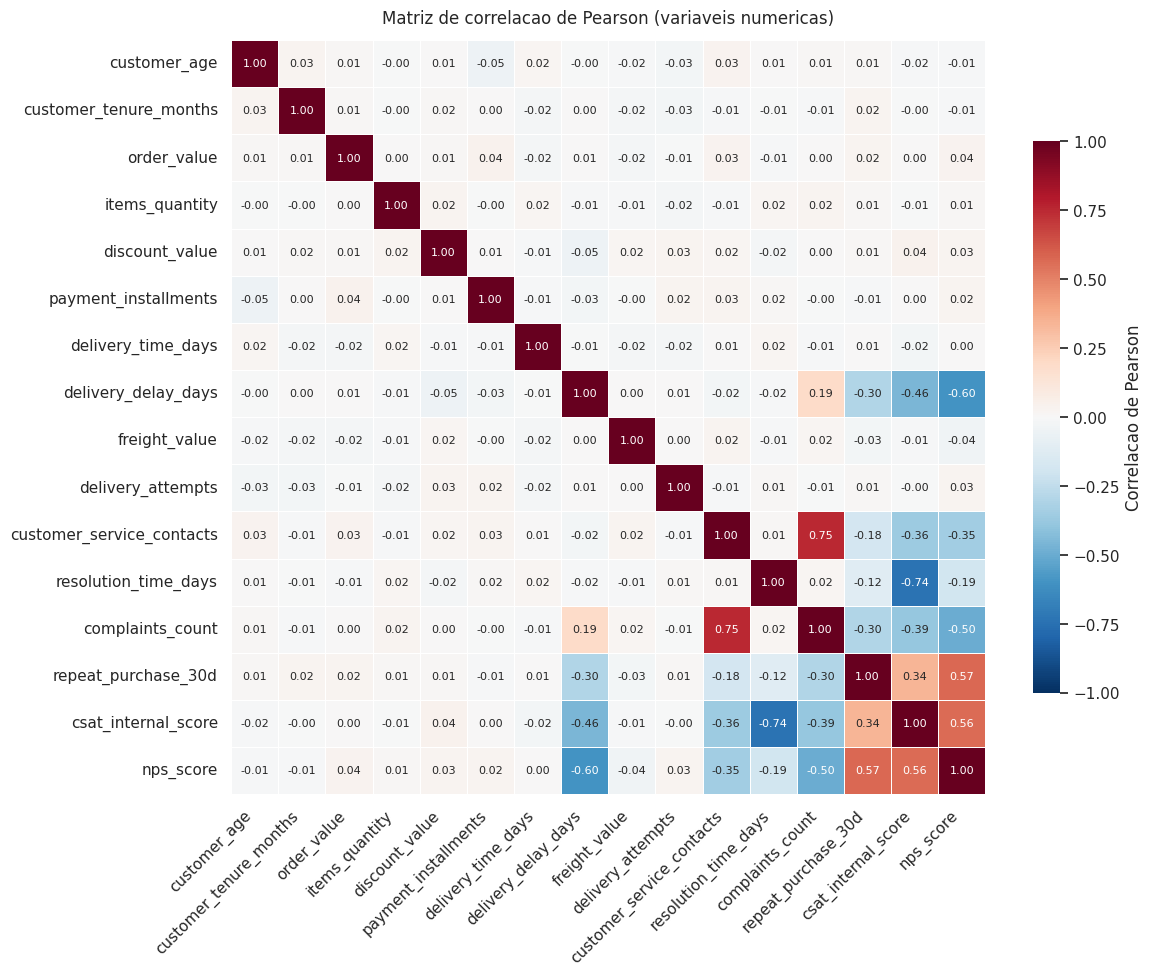

In [2]:
# Variaveis numericas relevantes (excluindo IDs e a copia houve_recompra_30d)
variaveis_numericas = [
    "customer_age", "customer_tenure_months",
    "order_value", "items_quantity", "discount_value", "payment_installments",
    "delivery_time_days", "delivery_delay_days", "freight_value", "delivery_attempts",
    "customer_service_contacts", "resolution_time_days", "complaints_count",
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_score",
]

# Matriz de correlacao de Pearson
matriz_corr = dados[variaveis_numericas].corr(method="pearson")

# Heatmap divergente em torno de zero
fig, eixo = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matriz_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlacao de Pearson"},
    ax=eixo,
)
eixo.set_title("Matriz de correlacao de Pearson (variaveis numericas)", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_2_heatmap_correlacao.png", dpi=120, bbox_inches="tight")
plt.show()

![Matriz de correlação de Pearson das variáveis numéricas](../reports/figures/04_eda/4_2_heatmap_correlacao.png)

**Como ler este gráfico:** uma **matriz quadrada** onde cada linha e cada coluna representa uma variável numérica. Cada célula mostra o **coeficiente de correlação de Pearson** entre as duas variáveis cruzadas, com o valor numérico anotado dentro. A escala de cores vai de **azul forte (correlação negativa, próxima de -1)** a **vermelho forte (correlação positiva, próxima de +1)**, passando pelo branco em zero (sem correlação linear). A **diagonal principal sempre é vermelho intenso (1,00)** porque é a correlação de cada variável com ela mesma. Para entender o impacto de cada variável na target, basta olhar a **linha ou coluna do `nps_score`** e identificar as cores mais fortes.

Algumas leituras importantes do heatmap.

**Coluna do `nps_score` (que é o que mais nos interessa nesta fase):** as cores mais fortes aparecem em poucas variáveis, e em duas direções diferentes.

Em **azul (correlação negativa)**, três variáveis se destacam: `delivery_delay_days`, `complaints_count` e `customer_service_contacts`. Faz sentido econômico: cliente com mais atraso, mais reclamações ou mais contatos no SAC tende a dar nota menor de NPS. A magnitude de `delivery_delay_days` (em torno de -0,60) é a maior associação linear negativa do dataset com a target.

Em **vermelho (correlação positiva)**, duas variáveis aparecem com força semelhante: `csat_internal_score` (aproximadamente +0,56) e `repeat_purchase_30d` (+0,57). A correlação alta com CSAT confirma a preocupação que tínhamos sobre target leakage (CSAT carrega informação parecida com a do NPS). A correlação alta com recompra é boa notícia para a hipótese H5: já antecipa que NPS deve mesmo prever recompra.

**Variáveis com correlação próxima de zero** com o NPS: idade, tenure, valor do pedido, quantidade de itens, parcelas, frete e tentativas de entrega têm coeficientes praticamente nulos. Isso era esperado para algumas dessas (idade, tenure parecem ter sido sorteadas independentemente da target no dataset sintético), mas há um caso suspeito: `delivery_time_days`. Logicamente, era para ter alguma relação, mas o coeficiente Pearson dela com NPS é praticamente zero.

**Atenção a esse achado:** Pearson capta só relação linear. Se o efeito do tempo de entrega for tipo "abaixo de 5 dias o NPS não muda muito; acima de 8 dias o NPS desaba", isso pode produzir correlação Pearson próxima de zero mesmo com relação real forte. Esse é exatamente o cenário descrito pela hipótese H1, e justifica investigar a variável com técnica diferente (segmentação por faixas) na seção 4.3.

**Outras observações úteis** que vão importar para a modelagem mais adiante: variáveis de atendimento têm correlações moderadas entre si (`complaints_count` × `customer_service_contacts`, `customer_service_contacts` × `resolution_time_days`), o que é colinearidade esperada. `freight_value` correlaciona positivamente com `order_value` (frete tende a subir com pedido maior). Nada disso surpreende, mas é bom ter mapeado.

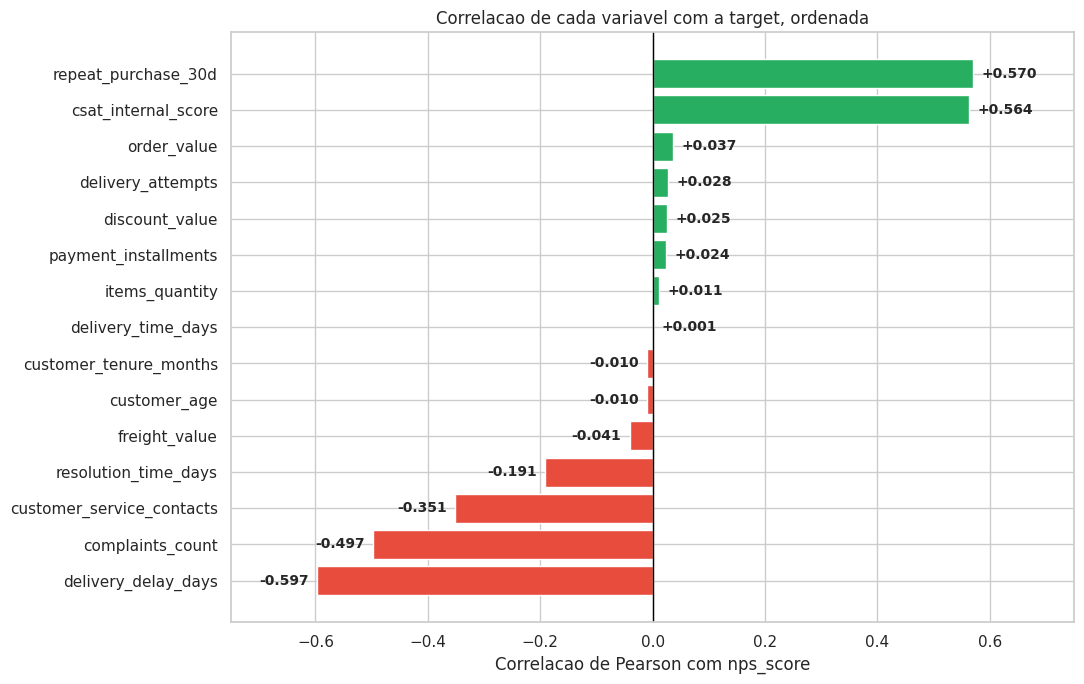

In [3]:
# Bar chart focado na correlacao de cada variavel com a target
correlacoes_com_nps = matriz_corr["nps_score"].drop("nps_score").sort_values()

# Cores: vermelho para correlacao negativa, verde para positiva
cores_barras = ["#e74c3c" if v < 0 else "#27ae60" for v in correlacoes_com_nps.values]

fig, eixo = plt.subplots(figsize=(11, 7))
barras = eixo.barh(correlacoes_com_nps.index, correlacoes_com_nps.values, color=cores_barras, edgecolor="white")

# Anota o valor numerico em cada barra
for i, v in enumerate(correlacoes_com_nps.values):
    deslocamento = 0.015 if v >= 0 else -0.015
    alinhamento = "left" if v >= 0 else "right"
    eixo.text(v + deslocamento, i, f"{v:+.3f}", va="center", ha=alinhamento, fontsize=10, fontweight="bold")

eixo.axvline(0, color="black", linewidth=1)
eixo.set_xlim(-0.75, 0.75)
eixo.set_xlabel("Correlacao de Pearson com nps_score")
eixo.set_title("Correlacao de cada variavel com a target, ordenada")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_2_correlacao_com_nps.png", dpi=120, bbox_inches="tight")
plt.show()

![Correlação de cada variável com a target ordenada](../reports/figures/04_eda/4_2_correlacao_com_nps.png)

**Como ler este gráfico:** o eixo X mostra o **coeficiente de correlação de Pearson** com `nps_score`, indo de -0,75 a +0,75. Cada barra horizontal é uma variável do dataset, ordenada da mais negativa (no topo) para a mais positiva (em baixo). **Barras vermelhas** indicam correlação negativa (a variável tende a baixar o NPS); **verdes** indicam correlação positiva (tendem a subir). O comprimento de cada barra é proporcional à força da relação. A linha vertical preta em zero é a referência para distinguir os dois lados, e barras muito curtas (próximas dela) significam variáveis sem relação linear detectável com a target.

O bar chart deixa o ranking explícito. Em valor absoluto, a hierarquia das correlações lineares com NPS é:

1. `delivery_delay_days` (-0,60)
2. `repeat_purchase_30d` (+0,57)
3. `csat_internal_score` (+0,56)
4. `complaints_count` (-0,50)
5. `customer_service_contacts` (-0,35)
6. `resolution_time_days` (-0,19)

E uma cauda longa de variáveis com correlação praticamente nula (`freight_value`, `customer_age`, `customer_tenure_months`, `delivery_time_days`, `items_quantity`, `payment_installments`, `discount_value`, `delivery_attempts`).

Esse panorama dá três pistas importantes para a sequência da EDA.

A **logística está claramente associada à target**, principalmente via atraso (`delivery_delay_days`), o que era a expectativa. A interação dessa variável com `order_value`, prevista pela hipótese H2, vai ser testada formalmente na seção 4.4.

O **atendimento entra como segundo bloco mais relevante**, mas com a ressalva já discutida no notebook 01: contatos com SAC e reclamações são possivelmente sintoma do problema, não causa. As hipóteses H3 (Service Recovery Paradox) e H6 (detrator silencioso) vão tentar separar esses efeitos.

E o **mistério do `delivery_time_days` quase nulo** vai ser o foco da hipótese H1: existe um ponto de ruptura, ou a variável de tempo total realmente não importa? Como Pearson é cego para não-linearidade, vamos precisar de outra abordagem para responder.

Com esse panorama em mente, as próximas seções vão testar cada uma das sete hipóteses formuladas no notebook 01.

## 4.3 Hipótese H1: ponto de ruptura em `delivery_time_days`

A hipótese H1, formulada na seção 1.6 do notebook 01, dizia que **existe um ponto de ruptura no `delivery_time_days` acima do qual o NPS cai de forma desproporcional ao aumento do tempo**. O panorama de correlações da seção 4.2 trouxe um sinal estranho: a correlação Pearson entre `delivery_time_days` e `nps_score` é praticamente zero. Mas isso não basta para rejeitar a hipótese, porque Pearson só capta relação linear. Se de fato existe um ponto de ruptura, a relação é não-linear, e Pearson seria cego para ela.

A forma certa de investigar é segmentar a variável em **faixas de interpretação de negócio** e comparar o NPS médio entre elas. Se houver ruptura, o NPS deve cair de forma visível ao passar de uma faixa para outra mais lenta.

### Faixas de tempo de entrega

Vou usar quatro categorias com significado prático para o negócio, todas dentro do range observado (2 a 14 dias):

| Faixa | Tempo |
|---|---|
| Rápido | até 3 dias |
| Normal | 4 a 7 dias |
| Lento | 8 a 11 dias |
| Muito lento | 12 dias ou mais |

Esses cortes refletem expectativas reais do mercado brasileiro de e-commerce: até 3 dias é território de "entrega rápida" tipo Amazon Prime e Mercado Livre Full; 4 a 7 dias é o padrão da maioria das plataformas; 8 a 11 começa a virar lento; 12 dias ou mais é considerado pesado.

NPS medio por faixa de tempo de entrega:
                     mean    std  count  ic_min  ic_max
delivery_time_days                                     
Rapido (<=3d)       4.294  2.551    386   4.040   4.548
Normal (4-7d)       4.439  2.470    752   4.262   4.616
Lento (8-11d)       4.391  2.511    757   4.212   4.570
Muito lento (12+d)  4.342  2.537    605   4.140   4.544


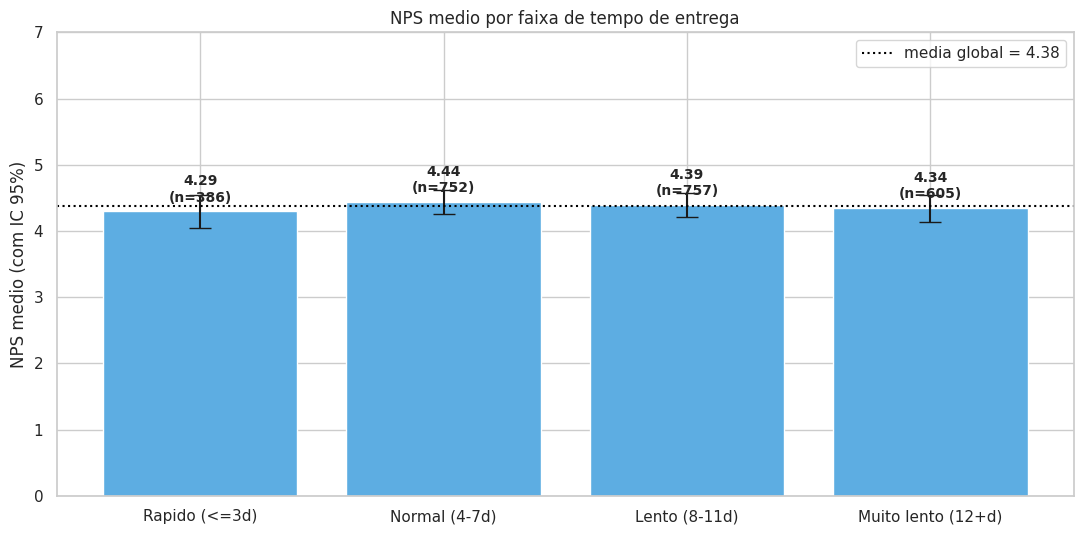

In [4]:
from scipy import stats

# Cria a coluna de faixa baseada em interpretacao de negocio
faixa_entrega = pd.cut(
    dados["delivery_time_days"],
    bins=[-float("inf"), 3, 7, 11, float("inf")],
    labels=["Rapido (<=3d)", "Normal (4-7d)", "Lento (8-11d)", "Muito lento (12+d)"],
)

# Calcula media, std, n e IC 95% para cada faixa
estats = dados.groupby(faixa_entrega, observed=True)["nps_score"].agg(["mean", "std", "count"]).round(3)
estats["se"] = estats["std"] / np.sqrt(estats["count"])
estats["ic_min"] = estats["mean"] - 1.96 * estats["se"]
estats["ic_max"] = estats["mean"] + 1.96 * estats["se"]

print("NPS medio por faixa de tempo de entrega:")
print(estats[["mean", "std", "count", "ic_min", "ic_max"]].round(3).to_string())

# Bar chart com error bars representando o IC 95%
fig, eixo = plt.subplots(figsize=(11, 5.5))
faixas_ordem = list(estats.index)
medias = estats["mean"].values
ic_baixo = (estats["mean"] - estats["ic_min"]).values
ic_alto = (estats["ic_max"] - estats["mean"]).values

barras = eixo.bar(
    faixas_ordem, medias,
    yerr=[ic_baixo, ic_alto],
    capsize=8,
    color="#5dade2",
    edgecolor="white",
)
for i, (m, n) in enumerate(zip(medias, estats["count"].values)):
    eixo.text(i, m + 0.15, f"{m:.2f}\n(n={n:,})", ha="center", fontsize=10, fontweight="bold")

# Linha da media global como referencia
media_global = dados["nps_score"].mean()
eixo.axhline(media_global, color="black", linestyle=":", linewidth=1.5, label=f"media global = {media_global:.2f}")

eixo.set_ylabel("NPS medio (com IC 95%)")
eixo.set_title("NPS medio por faixa de tempo de entrega")
eixo.set_ylim(0, 7)
eixo.legend(loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_3_nps_por_faixa_entrega.png", dpi=120, bbox_inches="tight")
plt.show()

![NPS médio por faixa de tempo de entrega](../reports/figures/04_eda/4_3_nps_por_faixa_entrega.png)

**Como ler este gráfico:** o eixo X tem as quatro faixas de tempo de entrega definidas por interpretação de negócio. A **altura de cada barra** é o NPS médio dos clientes daquela faixa, com o valor exato e o tamanho do grupo (n) anotados em cima. As **linhas verticais pretas no topo** são intervalos de confiança a 95%: representam o range provável onde está a média verdadeira da população, considerando a incerteza amostral. Quando os ICs de duas barras se sobrepõem, é um sinal forte de que as médias podem ser iguais. A **linha pontilhada preta horizontal** marca a média global do NPS no dataset, servindo como linha de referência.

O gráfico mostra um resultado **surpreendente e contraintuitivo**: as quatro faixas têm NPS médio praticamente idêntico, todos perto de 4,4. As barras de erro (intervalos de confiança a 95%) se sobrepõem entre as faixas, o que já é um forte indicativo visual de que não há diferença estatisticamente significativa.

Em outras palavras: cliente que recebeu o pedido em 3 dias dá nota parecida com cliente que recebeu em 14 dias. Não há ponto de ruptura visível, e nem mesmo uma queda gradual. A linha pontilhada da média global passa por todas as barras dentro do intervalo de confiança.

Vamos confirmar isso com um teste de hipóteses formal antes de cravar a conclusão.

In [5]:
# Teste t de Welch (variancias diferentes) entre o grupo mais rapido e o mais lento.
# Hipotese nula H0: medias iguais. Hipotese alternativa H1: medias diferentes.

grupo_rapido = dados[faixa_entrega == "Rapido (<=3d)"]["nps_score"]
grupo_muito_lento = dados[faixa_entrega == "Muito lento (12+d)"]["nps_score"]

t_stat, p_valor = stats.ttest_ind(grupo_rapido, grupo_muito_lento, equal_var=False)
diferenca_medias = grupo_rapido.mean() - grupo_muito_lento.mean()

# Intervalo de confianca 95% para a diferenca de medias (formula classica)
se_diff = np.sqrt(grupo_rapido.var(ddof=1) / len(grupo_rapido) +
                  grupo_muito_lento.var(ddof=1) / len(grupo_muito_lento))
ic_min_diff = diferenca_medias - 1.96 * se_diff
ic_max_diff = diferenca_medias + 1.96 * se_diff

print(f"Grupo Rapido (<=3d):       n = {len(grupo_rapido):>4,}, media = {grupo_rapido.mean():.3f}")
print(f"Grupo Muito lento (12+d):  n = {len(grupo_muito_lento):>4,}, media = {grupo_muito_lento.mean():.3f}")
print()
print(f"Diferenca de medias (rapido - muito lento): {diferenca_medias:+.3f}")
print(f"IC 95% para a diferenca: [{ic_min_diff:+.3f}, {ic_max_diff:+.3f}]")
print()
print(f"Estatistica t (Welch):     {t_stat:.3f}")
print(f"P-valor:                   {p_valor:.4f}")
print(f"Decisao a 5% de significancia: {'rejeitamos H0 (medias diferentes)' if p_valor < 0.05 else 'nao rejeitamos H0 (medias iguais)'}")

Grupo Rapido (<=3d):       n =  386, media = 4.294
Grupo Muito lento (12+d):  n =  605, media = 4.342

Diferenca de medias (rapido - muito lento): -0.048
IC 95% para a diferenca: [-0.373, +0.277]

Estatistica t (Welch):     -0.288
P-valor:                   0.7733
Decisao a 5% de significancia: nao rejeitamos H0 (medias iguais)


O teste t de Welch confirma o que o gráfico mostrava. A diferença de médias entre o grupo mais rápido e o mais lento é de apenas -0,048 pontos de NPS, e o intervalo de confiança a 95% inclui o zero (vai de aproximadamente -0,37 a +0,28). Isso significa que não temos evidência estatística suficiente para dizer que as médias são diferentes. O p-valor é alto (em torno de 0,77), muito acima do limiar usual de 5%.

**Conclusão sobre a hipótese H1:** rejeitada pelos dados. O tempo total de entrega, sozinho, não tem efeito detectável no NPS desta base. Não existe ponto de ruptura.

### O que isso significa de verdade

Esse resultado parece desconfortável à primeira vista, mas faz sentido quando combinado com o que vimos na seção 4.2: enquanto `delivery_time_days` tem correlação Pearson praticamente zero com NPS, `delivery_delay_days` (atraso em relação ao prometido) tem correlação de -0,60. Essa diferença é o achado central da seção.

A leitura de negócio é forte: **o cliente não fica satisfeito porque a entrega foi rápida em termos absolutos; ele fica satisfeito quando a empresa cumpre o prazo prometido**. Cliente que comprou um item de baixa prioridade e ouviu "entrega em 12 dias" está psicologicamente preparado para esperar 12 dias; se receber no prazo, ele não pune. O que machuca o NPS é a quebra de promessa, não o tempo em si.

Essa descoberta vira uma frase clara para o slide executivo:

> "Reduzir o tempo médio de entrega não é a alavanca prioritária para subir o NPS. A alavanca real é reduzir os atrasos, ou seja, melhorar a precisão da promessa, não a velocidade absoluta."

Operacionalmente, isso muda o tipo de investimento que faz sentido para a empresa: melhorar previsibilidade da operação (reduzir desvios) é provavelmente mais barato e mais impactante que tentar reduzir o tempo médio para todos os pedidos. A hipótese H2, na próxima seção, vai aprofundar esse efeito do atraso, agora em interação com o valor do pedido.

## 4.4 Hipótese H2: interação `delivery_delay_days` × `order_value`

A hipótese H2 dizia que **a tolerância a atraso depende do valor do pedido**, na direção esperada pelo negócio: cliente que paga mais (ticket alto) seria mais sensível a atrasos do que cliente que paga menos. A forma estatística de testar isso é uma **regressão linear múltipla com termo de interação**: ajustar dois modelos, um sem interação e outro com, e verificar se o termo de interação melhora a explicação da variabilidade do NPS de forma significativa.

A técnica usada é exatamente o que foi visto na aula de regressão linear: estimar coeficientes, ler p-valores e comparar R² entre modelos. Vou usar a biblioteca `statsmodels`, que produz a saída em formato de tabela acadêmica padrão.

In [6]:
import statsmodels.formula.api as smf

# Modelo 1: efeito principal das duas variaveis, sem interacao
modelo_1 = smf.ols("nps_score ~ delivery_delay_days + order_value", data=dados).fit()

# Modelo 2: com termo de interacao delivery_delay_days * order_value
# A notacao "*" no statsmodels gera os efeitos principais E o termo de interacao automaticamente.
modelo_2 = smf.ols("nps_score ~ delivery_delay_days * order_value", data=dados).fit()

print("=== MODELO 1 (sem interacao) ===")
print(modelo_1.summary().tables[1])
print(f"R-quadrado: {modelo_1.rsquared:.4f}")

print("\n=== MODELO 2 (com interacao) ===")
print(modelo_2.summary().tables[1])
print(f"R-quadrado: {modelo_2.rsquared:.4f}")

print(f"\nGanho de R-quadrado ao adicionar a interacao: {modelo_2.rsquared - modelo_1.rsquared:+.4f}")
print(f"P-valor do coeficiente de interacao: {modelo_2.pvalues['delivery_delay_days:order_value']:.4f}")

=== MODELO 1 (sem interacao) ===
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.4815      0.094     68.807      0.000       6.297       6.666
delivery_delay_days    -1.0312      0.028    -37.273      0.000      -1.085      -0.977
order_value             0.0004      0.000      2.530      0.011     7.9e-05       0.001
R-quadrado: 0.3584

=== MODELO 2 (com interacao) ===
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           6.4316      0.131     49.160      0.000       6.175       6.688
delivery_delay_days                -1.0080      0.050    -19.990      0.000      -1.107      -0.909
order_value                         0.0005      0.000      1.838      0.06

**Como ler a tabela de coeficientes:** cada linha é uma variável (ou termo) do modelo. As colunas mostram, da esquerda para a direita: o **coeficiente estimado** (`coef`), o erro padrão (`std err`), a estatística de teste (`t`), o **p-valor** (`P>|t|`) e o intervalo de confiança a 95% (`[0.025, 0.975]`).

A regra prática é: o coeficiente diz quanto a target muda quando a variável aumenta em uma unidade. O p-valor responde "se o coeficiente verdadeiro for zero, qual a probabilidade de eu ver um valor desse por acaso?". Quanto menor, mais evidência contra o coeficiente ser zero. **P-valor abaixo de 0,05 indica significância estatística** ao nível de 5%.

O `R-quadrado` no rodapé é a fração da variância da target explicada pelo modelo (entre 0 e 1). Quanto mais alto, melhor o modelo se ajustou aos dados.

Lendo os números, três coisas saltam da tabela.

**No Modelo 1:** o coeficiente de `delivery_delay_days` é -1,03 (cada dia de atraso reduz o NPS em aproximadamente 1 ponto), com p-valor praticamente zero (forte evidência de efeito real). O coeficiente de `order_value` é minúsculo (+0,0004), com p-valor borderline (0,011). O R² é 0,36, o que significa que essas duas variáveis sozinhas já explicam **36% da variabilidade do NPS**, um número alto considerando que estamos usando apenas duas variáveis.

**No Modelo 2:** o termo de interação `delivery_delay_days:order_value` tem coeficiente de -5,46 × 10⁻⁵ e **p-valor de 0,58**, longe de significativo. O R² do modelo com interação é praticamente idêntico ao sem interação (0,3584 vs 0,3584).

**Conclusão sobre a hipótese H2:** rejeitada pelos dados. Não há evidência de que clientes com pedidos de valor mais alto sejam mais sensíveis a atrasos do que clientes de pedidos baratos. O efeito do atraso é estatisticamente o mesmo, independente do `order_value`.

Antes de fechar a interpretação, vale visualizar isso para confirmar a leitura dos coeficientes.

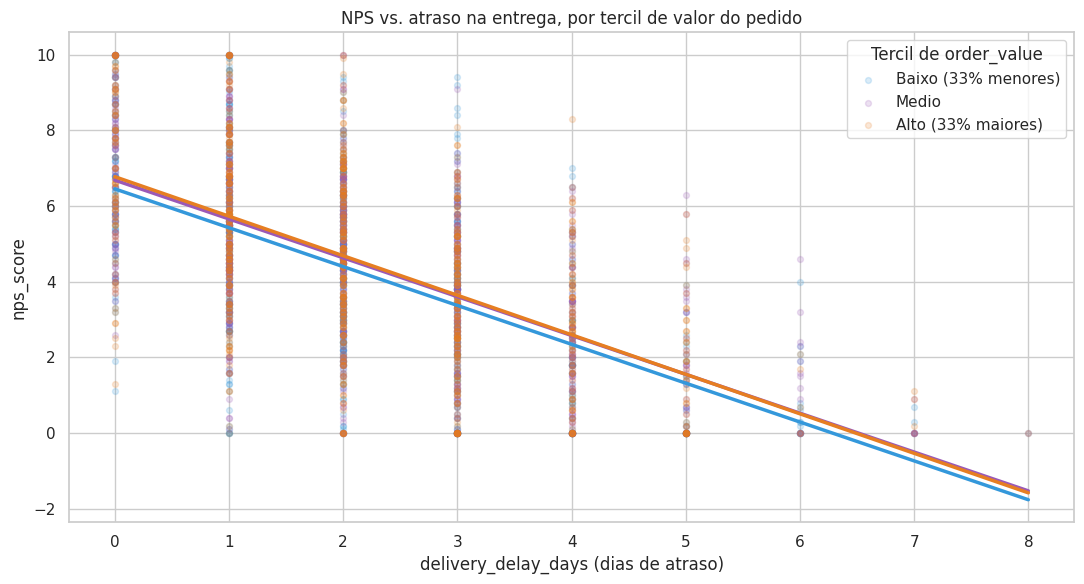

In [7]:
# Visualizacao da interacao: scatter de delivery_delay_days vs nps_score, colorido por
# tercil de order_value. Se houver interacao real, as 3 linhas de tendencia teriam
# inclinacoes diferentes; se nao houver, as inclinacoes serao parecidas.

dados_viz = dados.copy()
dados_viz["tercil_pedido"] = pd.qcut(
    dados_viz["order_value"],
    q=3,
    labels=["Baixo (33% menores)", "Medio", "Alto (33% maiores)"],
)

# Cores diferentes para cada tercil
paleta_tercis = {
    "Baixo (33% menores)": "#3498db",
    "Medio":               "#9b59b6",
    "Alto (33% maiores)":  "#e67e22",
}

fig, eixo = plt.subplots(figsize=(11, 6))

# Para cada tercil, plota os pontos com leve transparencia e a linha de regressao
for nome_tercil, cor in paleta_tercis.items():
    subset = dados_viz[dados_viz["tercil_pedido"] == nome_tercil]
    sns.regplot(
        data=subset,
        x="delivery_delay_days",
        y="nps_score",
        scatter_kws={"alpha": 0.18, "s": 18, "color": cor},
        line_kws={"color": cor, "linewidth": 2.5},
        ci=None,
        ax=eixo,
        label=nome_tercil,
    )

eixo.set_xlabel("delivery_delay_days (dias de atraso)")
eixo.set_ylabel("nps_score")
eixo.set_title("NPS vs. atraso na entrega, por tercil de valor do pedido")
eixo.legend(title="Tercil de order_value", loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_4_interacao_atraso_valor.png", dpi=120, bbox_inches="tight")
plt.show()

![NPS vs atraso por tercil de valor do pedido](../reports/figures/04_eda/4_4_interacao_atraso_valor.png)

**Como ler este gráfico:** o eixo X mostra os dias de atraso na entrega; o eixo Y mostra o `nps_score`. Cada ponto é um pedido individual, e os clientes foram divididos em **três grupos pelos tercis do `order_value`**: 33% com pedidos de menor valor (azul), 33% intermediários (roxo), 33% com pedidos de maior valor (laranja).

Para cada grupo foi traçada uma **linha de regressão linear simples** (`nps_score ~ delivery_delay_days` dentro do grupo). A inclinação dessa linha indica quanto o NPS cai por cada dia de atraso, naquele grupo específico.

**O que procurar para confirmar ou rejeitar H2:** se a hipótese estiver correta (clientes de ticket alto mais sensíveis), a linha laranja deveria ter inclinação **mais negativa** (mais íngreme para baixo) do que as outras duas. Se as três linhas tiverem inclinação parecida, todos os clientes reagem de forma equivalente ao atraso, e a hipótese cai.

As três linhas estão **praticamente paralelas e sobrepostas**. A inclinação é aproximadamente a mesma em todos os tercis: cada dia de atraso reduz o NPS em algo próximo de 1 ponto, independente de o cliente ter feito um pedido barato, médio ou caro. Isso confirma visualmente o que o modelo de regressão já tinha mostrado: não existe interação significativa entre `delivery_delay_days` e `order_value`.

### Interpretação de negócio

O resultado contradiz uma intuição comum. Faz sentido pensar que cliente que pagou caro deveria ficar mais furioso com atraso, mas no nosso dataset isso não acontece. **Atraso machuca todos os clientes mais ou menos na mesma medida**, e o que define quanto o NPS cai é a magnitude do atraso, não o valor do pedido.

Essa descoberta tem três implicações práticas para a empresa.

**Não vale priorizar logística por ticket.** Estratégias como "vamos garantir entrega no prazo só para pedidos acima de R$ 500" não vão fazer o NPS subir tanto quanto seria esperado, porque cliente de R$ 100 também está sendo punido pelo atraso na mesma proporção.

**A alavanca correta é universal: reduzir atrasos para todos.** Como o efeito é uniforme, qualquer melhoria operacional que reduza atrasos médios vai mexer no NPS de toda a base.

**O modelo simples (apenas atraso) já explica 36% do NPS.** Isso é muito para uma variável só. Reforça o achado da seção 4.3 de que **previsibilidade da entrega é a alavanca principal**, e antecipa que `delivery_delay_days` provavelmente vai ser o preditor número um nos modelos do notebook 05.

## 4.5 Hipótese H3: Service Recovery Paradox

A hipótese H3, formulada na seção 1.6, dizia que **cliente que reclamou e teve resolução rápida tem NPS comparável ao de quem não reclamou**. A ideia por trás é o conceito de Service Recovery Paradox: em alguns contextos, atender bem após uma falha pode até elevar a satisfação acima do nível original, transformando um possível detrator em promotor.

Como vimos na seção 2.5, o dataset tem mediana de **4 reclamações por cliente**, ou seja, quase ninguém na base se encaixa na definição original de "não reclamou". Por isso a hipótese foi reformulada na seção 2.8 como **viável com ajuste**: em vez de comparar "reclamou" vs "não reclamou", vamos comparar "muitas reclamações" vs "poucas reclamações", combinado com a velocidade de resolução do SAC.

### Definição dos quatro grupos

Usando os quartis do dataset, defino quatro grupos cruzando os dois eixos:

| Grupo | Reclamações | Tempo de resolução |
|---|---|---|
| **Poucas + Rápida** | até 3 (Q1 inferior) | até 2 dias (Q1 inferior) |
| **Poucas + Lenta** | até 3 | 8 dias ou mais (Q4 superior) |
| **Muitas + Rápida** | 5 ou mais (Q4 superior) | até 2 dias |
| **Muitas + Lenta** | 5 ou mais | 8 dias ou mais |

Excluo os clientes "intermediários" da análise para deixar o contraste mais limpo: quero comparar extremos contra extremos. Isso reduz o tamanho amostral mas torna o efeito mais visível, e cada grupo ainda tem mais de 200 observações, o suficiente para inferência estatística.

Tamanho dos grupos:
nivel_reclamacao  velocidade_sac
Muitas (>=5)      Lenta (>=8d)      345
                  Rapida (<=2d)     231
Poucas (<=3)      Lenta (>=8d)      304
                  Rapida (<=2d)     243


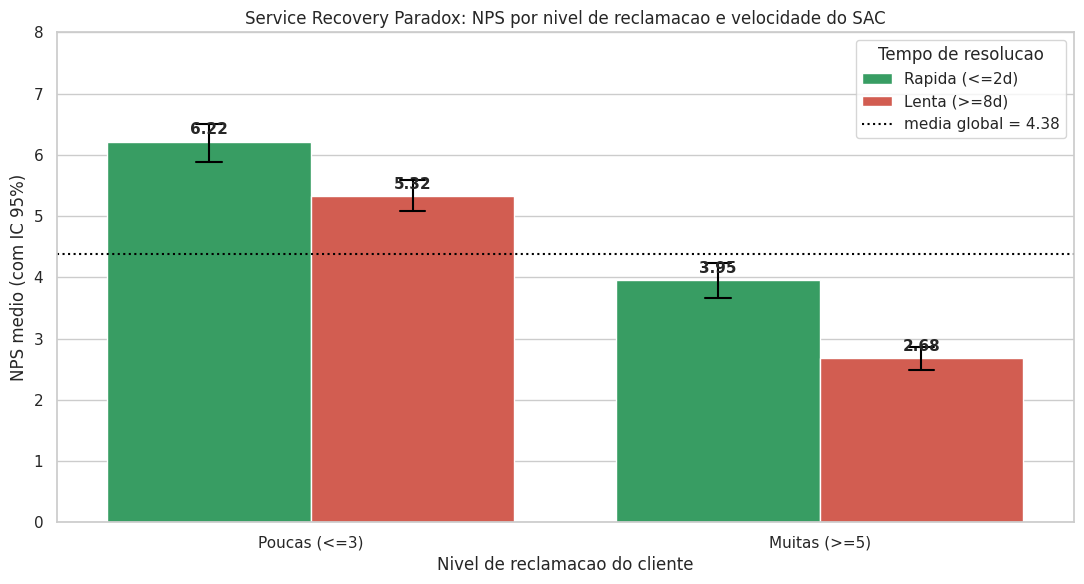

In [8]:
# Define os 4 grupos cruzando reclamacoes (poucas/muitas) e velocidade do SAC (rapida/lenta)
poucas = dados["complaints_count"] <= 3
muitas = dados["complaints_count"] >= 5
rapida = dados["resolution_time_days"] <= 2
lenta = dados["resolution_time_days"] >= 8

extremos = dados[(poucas | muitas) & (rapida | lenta)].copy()
extremos["nivel_reclamacao"] = np.where(extremos["complaints_count"] <= 3, "Poucas (<=3)", "Muitas (>=5)")
extremos["velocidade_sac"] = np.where(extremos["resolution_time_days"] <= 2, "Rapida (<=2d)", "Lenta (>=8d)")

# Tamanho de cada grupo
print("Tamanho dos grupos:")
print(extremos.groupby(["nivel_reclamacao", "velocidade_sac"]).size().to_string())

# Bar chart agrupado: nivel_reclamacao no eixo X, velocidade_sac como hue
fig, eixo = plt.subplots(figsize=(11, 6))

paleta_velocidade = {"Rapida (<=2d)": "#27ae60", "Lenta (>=8d)": "#e74c3c"}

sns.barplot(
    data=extremos,
    x="nivel_reclamacao",
    y="nps_score",
    hue="velocidade_sac",
    order=["Poucas (<=3)", "Muitas (>=5)"],
    hue_order=["Rapida (<=2d)", "Lenta (>=8d)"],
    palette=paleta_velocidade,
    errorbar=("ci", 95),
    capsize=0.1,
    err_kws={"linewidth": 1.5, "color": "black"},
    ax=eixo,
)

# Anota os valores em cima de cada barra
for container in eixo.containers:
    eixo.bar_label(container, fmt="%.2f", padding=3, fontsize=11, fontweight="bold")

# Linha da media global como referencia
media_global = dados["nps_score"].mean()
eixo.axhline(media_global, color="black", linestyle=":", linewidth=1.5, label=f"media global = {media_global:.2f}")

eixo.set_xlabel("Nivel de reclamacao do cliente")
eixo.set_ylabel("NPS medio (com IC 95%)")
eixo.set_title("Service Recovery Paradox: NPS por nivel de reclamacao e velocidade do SAC")
eixo.set_ylim(0, 8)
eixo.legend(title="Tempo de resolucao", loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_5_service_recovery_paradox.png", dpi=120, bbox_inches="tight")
plt.show()

![NPS por nível de reclamação e velocidade do SAC](../reports/figures/04_eda/4_5_service_recovery_paradox.png)

**Como ler este gráfico:** o eixo X separa os clientes em dois grupos pelo número de reclamações: à esquerda quem teve **poucas reclamações** (até 3), à direita quem teve **muitas** (5 ou mais). Em cada grupo aparecem **duas barras lado a lado** representando a velocidade de resolução do SAC: **verde** para resolução rápida (até 2 dias), **vermelho** para resolução lenta (8 dias ou mais).

A altura de cada barra é o **NPS médio** dos clientes daquele subgrupo, com o valor exato anotado acima. As **linhas verticais pretas** no topo de cada barra são intervalos de confiança a 95%, mostrando a faixa onde está a média verdadeira da população.

A **linha pontilhada preta horizontal** é a média global do NPS no dataset (4,38), servindo como linha de referência.

**O que procurar:**
- Comparar a barra verde da esquerda com a verde da direita responde "resolução rápida no grupo de muitas reclamações chega ao mesmo nível de quem reclama pouco?" — isso é a hipótese forte do paradox.
- Comparar a barra verde com a vermelha **dentro de cada nível de reclamação** mostra se SAC rápido faz diferença.
- Quanto mais sobrepostas as barras de erro, menos diferença significativa entre os grupos.

Visualmente já dá para ver dois efeitos importantes.

**O paradox forte não acontece.** A barra verde de "Muitas reclamações + Rápida" (3,95) está bem abaixo da barra verde de "Poucas reclamações + Rápida" (6,22). Os intervalos de confiança não se sobrepõem nem de longe. Cliente que reclamou muito não vira promotor só porque foi atendido rápido — ele continua significativamente menos satisfeito do que quem nunca teve problema.

**Mas a velocidade do SAC tem efeito real.** Dentro do grupo de muitas reclamações, a barra verde (3,95) é claramente mais alta que a vermelha (2,69). A diferença é de mais de um ponto de NPS, e os intervalos de confiança não se sobrepõem. Isso significa que resolver rápido **não cura, mas amortece**: cliente em situação ruim fica menos detrator quando a empresa age rápido.

Vamos confirmar esses dois efeitos com testes formais.

In [9]:
# Filtra cada grupo para teste t
g1 = extremos.query("nivel_reclamacao == \"Poucas (<=3)\" and velocidade_sac == \"Rapida (<=2d)\"")["nps_score"]
g3 = extremos.query("nivel_reclamacao == \"Muitas (>=5)\" and velocidade_sac == \"Rapida (<=2d)\"")["nps_score"]
g4 = extremos.query("nivel_reclamacao == \"Muitas (>=5)\" and velocidade_sac == \"Lenta (>=8d)\"")["nps_score"]

def teste_diferenca(amostra_a: pd.Series, amostra_b: pd.Series, nome_a: str, nome_b: str) -> None:
    """Aplica teste t de Welch e imprime resultado com IC 95% para a diferenca."""
    t_stat, p_valor = stats.ttest_ind(amostra_a, amostra_b, equal_var=False)
    diferenca = amostra_a.mean() - amostra_b.mean()
    se = np.sqrt(amostra_a.var(ddof=1) / len(amostra_a) + amostra_b.var(ddof=1) / len(amostra_b))
    ic_min = diferenca - 1.96 * se
    ic_max = diferenca + 1.96 * se
    print(f"  {nome_a} (n={len(amostra_a)}, media={amostra_a.mean():.3f}) vs {nome_b} (n={len(amostra_b)}, media={amostra_b.mean():.3f})")
    print(f"  Diferenca: {diferenca:+.3f} | IC 95%: [{ic_min:+.3f}, {ic_max:+.3f}] | t={t_stat:.3f} | p-valor={p_valor:.6f}")
    print(f"  Decisao: {'rejeita H0 (medias diferentes)' if p_valor < 0.05 else 'nao rejeita H0'}")
    print()

print("Teste 1: Paradox forte — cliente que reclamou muito + foi atendido rapido")
print("         atinge o NPS de quem reclamou pouco?")
teste_diferenca(g1, g3, "Poucas + Rapida", "Muitas + Rapida")

print("Teste 2: Velocidade do SAC importa? (dentro de muitas reclamacoes)")
teste_diferenca(g3, g4, "Muitas + Rapida", "Muitas + Lenta")

Teste 1: Paradox forte — cliente que reclamou muito + foi atendido rapido
         atinge o NPS de quem reclamou pouco?
  Poucas + Rapida (n=243, media=6.216) vs Muitas + Rapida (n=231, media=3.951)
  Diferenca: +2.265 | IC 95%: [+1.847, +2.683] | t=10.620 | p-valor=0.000000
  Decisao: rejeita H0 (medias diferentes)

Teste 2: Velocidade do SAC importa? (dentro de muitas reclamacoes)
  Muitas + Rapida (n=231, media=3.951) vs Muitas + Lenta (n=345, media=2.685)
  Diferenca: +1.266 | IC 95%: [+0.922, +1.611] | t=7.210 | p-valor=0.000000
  Decisao: rejeita H0 (medias diferentes)



Os dois testes confirmam o que o gráfico mostrava.

**Teste 1 (paradox forte):** a diferença entre "Poucas + Rápida" e "Muitas + Rápida" é de +2,27 pontos de NPS, com IC 95% bem afastado do zero e p-valor próximo de zero. Existe diferença real e grande entre os dois grupos. **A versão forte da hipótese H3 está rejeitada**: resolução rápida não recupera o cliente ao patamar de quem nunca teve problema.

**Teste 2 (velocidade do SAC importa):** a diferença entre "Muitas + Rápida" e "Muitas + Lenta" é de +1,27 pontos, também com p-valor próximo de zero. **Rrespostas rápidas do SAC fazem diferença mensurável** mesmo quando o cliente já tem muitas reclamações. A versão atenuada da hipótese (que reformulei na seção 2.8) está confirmada.

### Interpretação de negócio

A leitura prática é honesta sobre o que SAC consegue e não consegue fazer.

**SAC rápido não substitui prevenção.** Quando o cliente já chegou ao ponto de fazer cinco ou mais reclamações, nem o atendimento mais ágil consegue trazer o NPS de volta ao nível dos clientes "tranquilos". Existe um teto inferior em torno de 4 pontos para esse perfil, independente de quanto a empresa corra para responder. Investimento em SAC sozinho não é estratégia de recuperação completa; é amortecedor de queda.

**Mas vale investir em rapidez no SAC.** O gap de 1,27 pontos entre resolução rápida e lenta dentro do grupo de muitas reclamações é grande em termos de NPS. Considerando que esse grupo provavelmente representa os clientes em maior risco de churn, cada ponto a mais de NPS pode significar a diferença entre voltar a comprar ou não. Reduzir o tempo de resolução do SAC de 8 dias para 2 dias tem retorno mensurável e direto.

**Conclusão para a recomendação:** o SAC tem papel claro como **mitigador**, não como **recuperador completo**. A estratégia ideal combina (1) reduzir as causas que fazem o cliente reclamar (ou seja, atacar atrasos e falhas operacionais que vimos na 4.3 e 4.4), e (2) garantir resolução rápida quando a reclamação acontece, para amortecer o dano. Atacar só o segundo ponto sem o primeiro não vai mover o NPS médio da empresa, porque a maior parte da queda já aconteceu antes do cliente chegar ao SAC.